In [2]:
# Levi Félix Barbosa - 579420

import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
# exercício 1 - normalizar os dados
pressao_dataset = np.genfromtxt('./pressão', delimiter = ',', skip_header=1)
peixe_dataset = np.genfromtxt('./peixe', delimiter=',')

media_x= np.mean(peixe_dataset, axis = 0)
N = (peixe_dataset).shape[0]
desvio_x = np.sqrt( (np.mean( (peixe_dataset - media_x ) ** 2  * N / (N-1), axis=0) ) )
x_norm = (peixe_dataset - media_x) / desvio_x
x_norm

array([[-1.55384675, -1.32630725, -1.87170902],
       [-1.23940207, -1.32630725, -1.34874483],
       [-0.94741773, -1.32630725, -0.74300933],
       [-0.63297305, -1.32630725, -0.38182543],
       [-0.31852837, -1.32630725,  0.00193247],
       [-0.0040837 , -1.32630725,  0.32173072],
       [ 0.31036098, -1.32630725,  0.6227173 ],
       [ 0.62480566, -1.32630725,  1.02152453],
       [ 0.93925034, -1.32630725,  1.07043485],
       [ 1.25369501, -1.32630725,  1.10053351],
       [ 1.56813969, -1.32630725,  1.1231075 ],
       [-1.55384675, -0.44210242, -1.86794669],
       [-1.23940207, -0.44210242, -1.42399148],
       [-0.94741773, -0.44210242, -0.75053399],
       [-0.63297305, -0.44210242, -0.2275698 ],
       [-0.31852837, -0.44210242,  0.11104011],
       [-0.0040837 , -0.44210242,  0.68291462],
       [ 0.31036098, -0.44210242,  0.90865456],
       [ 0.62480566, -0.44210242,  1.04409852],
       [ 0.93925034, -0.44210242,  1.07419718],
       [ 1.25369501, -0.44210242,  1.123

In [4]:
# exercício 2 - aproximar raizes 

x = 1.4
e = 0.01
while abs(x*x - 2) > e:
    x = x - (x*x-2)/(2*x)
x*x-2

0.0002040816326531747

In [9]:
# questão 1 - implementar o OLS
# obs: já vamos usar os dados normalizados que obtemos no exercício 1

X = np.concatenate([np.ones((N, 1)), x_norm[:, [0, 1]]], axis=1)
y = x_norm[:, [2]]
w = np.linalg.inv(X.T @ X) @ X.T @ y

y_pred = X @ w

# vamos desnormalizar pra calcular o rmse

y_pred_desnorm = desvio_x[2] * y_pred + media_x[2]
y_real = peixe_dataset[:, [2]]



rmse = math.sqrt(np.mean( (y_real - y_pred_desnorm) ** 2 ))
rmse

579.1819827887995

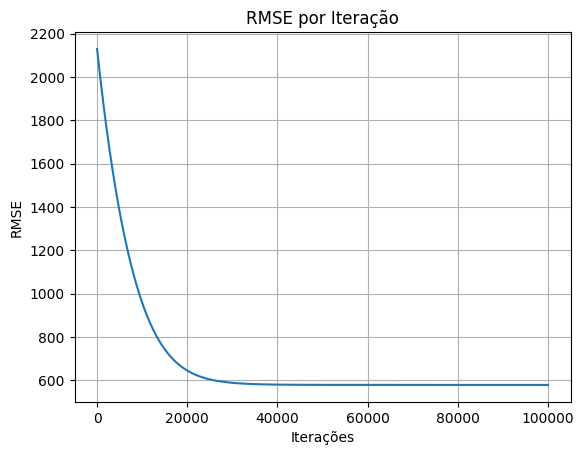

In [89]:
# questão 2 da lista - implementar o GD

alfa = 0.0001

X = np.concatenate([np.ones((N, 1)), x_norm[:, [0, 1]]], axis=1)
y = x_norm[:, [2]]

w_par = np.ones((3,1))
y_pred = X @ w_par

e = y - y_pred

t = 1

rmse_hist = []
for t in range(0, 100000):
    y_pred = X @ w_par
    e = y - y_pred
    w_par = w_par + alfa * (X.T @ e) / N

    # para plotar:
    y_pred_desnorm = desvio_x[2] * y_pred + media_x[2]
    y_real = peixe_dataset[:, [2]]
    rsme_atual = math.sqrt(np.mean( (y_real - y_pred_desnorm) ** 2 ))
    rmse_hist.append(rsme_atual)

# agora, vamos desnormalizar para calcular o rmse

y_pred_desnorm = desvio_x[2] * y_pred + media_x[2]
y_real = peixe_dataset[:, [2]]

rmse = math.sqrt(np.mean( (y_real - y_pred_desnorm) ** 2 ))
rmse

# o resultado é bem próximo do OLS.

# vamos plotar o gráfico de rmse por iteração
plt.plot(range(len(rmse_hist)), rmse_hist)
plt.title("RMSE por Iteração")
plt.xlabel("Iterações")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()




579.1879439124956


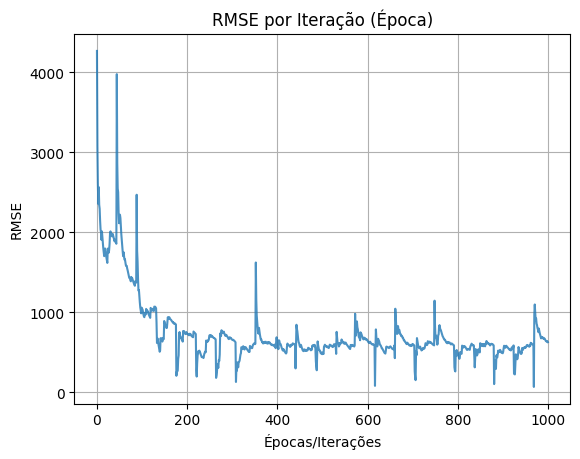

In [86]:
# questão 3 da lista - implementar o SGD

import matplotlib.pyplot as plt



alfa = 0.008

X = np.concatenate([np.ones((N, 1)), x_norm[:, [0, 1]]], axis=1)
y = x_norm[:, [2]]  

w_par = np.ones((3,1))
t = 1

# vamos plotar também o gráfico do rmse pelas épocas
rmse_hist = []


while t < 10000:
    indices = np.random.permutation(N)
    x_emb = X[indices]
    y_emb = y[indices]
    erros_epoca = []
    for i in range(0, N):
        t = t+1
        y_pred_i = x_emb[i] @ w_par
        e_i = y_emb[i] - y_pred_i
        w_par = w_par + alfa * (x_emb[i].reshape(-1, 1) * e_i) 
        
        erro_quad = (e_i[0] * desvio_x[2]) ** 2
        erros_epoca.append(erro_quad)  
        rmse_epoca = math.sqrt(np.mean(erros_epoca))
        rmse_hist.append(rmse_epoca)
    

y_pred = X @ w_par

# vamos calcular o rmse

y_pred_desnorm = desvio_x[2] * y_pred + media_x[2]
y_real = peixe_dataset[:, [2]]

rmse = math.sqrt(np.mean( (y_real - y_pred_desnorm) ** 2 ))
print(rmse)

# plotando

corte = 1000
plt.plot(range(corte), rmse_hist[:corte], alpha = 0.8)
plt.title("RMSE por Iteração (Época)")
plt.xlabel("Épocas/Iterações")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()